# Preparations

In [1]:
import pandas as pd
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, zscore, median_abs_deviation, f_oneway, kruskal, gaussian_kde, chi2, norm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
import numpy as np
import re 
import seaborn as sns
import math
from math import erf, sqrt
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import scikit_posthocs as sp
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from itertools import combinations, product
import patchworklib as pw
from matplotlib.gridspec import GridSpec
import string
import pylab 
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from openpyxl.utils import get_column_letter
from textwrap import fill

import warnings
warnings.filterwarnings('ignore')
from scipy.stats import f as f_dist
from scipy.stats import t as t_dist
from typing import Optional
from matplotlib.colors import TwoSlopeNorm




from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


<Figure size 100x100 with 0 Axes>

In [41]:
# Load dataset
data = pd.read_excel("./replicates_Ki_checked_for_statistic.xlsx")


## Data prep

In [42]:
print(data["concentration radioligand (nM)"].dtype) # cannot use object for numbers- needs to be converted to float

float64


In [43]:
#convert to float
# Convert radioligand concentration column to numeric values;
# non-numeric entries are coerced to NaN to ensure compatibility with statistical analyses
data["concentration radioligand (nM)"] = pd.to_numeric(data["concentration radioligand (nM)"].copy(), errors="coerce")

In [44]:
print(data["concentration radioligand (nM)"].dtype) #check if type has changed to float

float64


## Subdataframes for each investigated compound


In [45]:
Rimonabant_df = data[data.pubchem_cid == 104850.0].copy() 
WIN_df = data[data.pubchem_cid == 5311501.0].copy() 
CP_df = data[data.pubchem_cid == 104895.0].copy() 
Anandamide_df = data[data.pubchem_cid == 5281969.0].copy() 
THC9_df = data[data.pubchem_cid == 16078.0].copy()
JWH018_df = data[data.pubchem_cid == 10382701.0].copy()
SR_df = data[data.pubchem_cid == 3081355.0].copy()
THC8_df = data[data.pubchem_cid == 638026.0].copy()
CHEMBL_df = data[data.pubchem_cid == 44208932.0].copy()
JWH133_df = data[data.pubchem_cid == 6918505.0].copy() 

### Anandamide/ PMSF outlier investigation


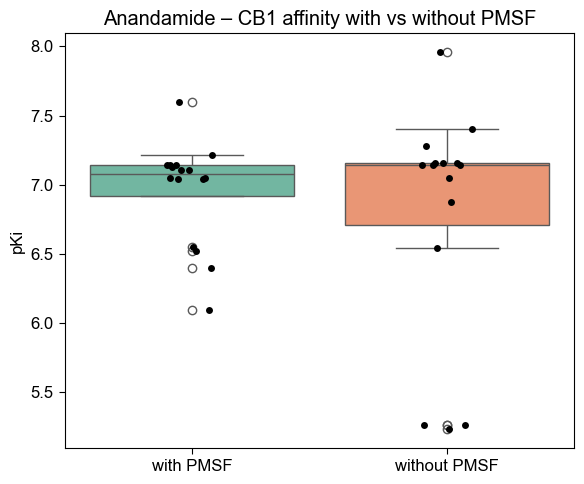

In [46]:

df = Anandamide_df.copy()

# -----------------------------
# 1) PMSF Variable erzeugen
# -----------------------------
df["PMSF"] = df["substance_added"].str.contains("pmsf", case=False, na=False)

# Label für Plot
df["PMSF_label"] = df["PMSF"].map({True: "with PMSF", False: "without PMSF"})

# -----------------------------
# 2) Plot (pKi)
# -----------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="PMSF_label",
    y="value_pKi",
    palette="Set2"
)

sns.stripplot(
    data=df,
    x="PMSF_label",
    y="value_pKi",
    color="black",
    size=5,
    jitter=True
)

plt.ylabel("pKi")
plt.xlabel("")
plt.title("Anandamide – CB1 affinity with vs without PMSF")

plt.tight_layout()
plt.show()

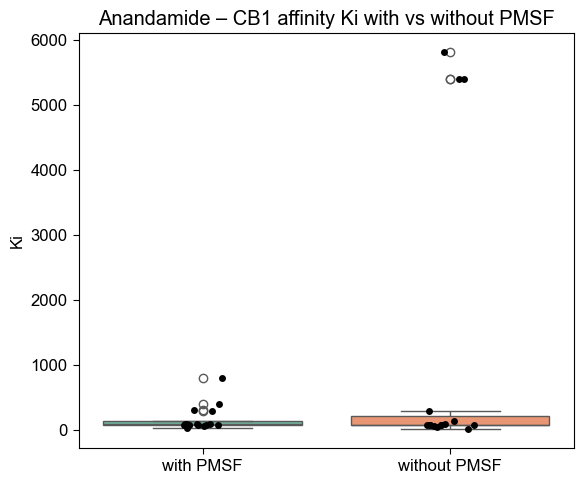

In [47]:

df = Anandamide_df.copy()

# -----------------------------
# 1) PMSF Variable erzeugen
# -----------------------------
df["PMSF"] = df["substance_added"].str.contains("pmsf", case=False, na=False)

# Label für Plot
df["PMSF_label"] = df["PMSF"].map({True: "with PMSF", False: "without PMSF"})

# -----------------------------
# 2) Plot (pKi)
# -----------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="PMSF_label",
    y="value",
    palette="Set2"
)

sns.stripplot(
    data=df,
    x="PMSF_label",
    y="value",
    color="black",
    size=5,
    jitter=True
)

plt.ylabel("Ki")
plt.xlabel("")
plt.title("Anandamide – CB1 affinity Ki with vs without PMSF")

plt.tight_layout()
plt.show()

#### remove three anandamide outliers



In [48]:
Anandamide_df.loc[
    Anandamide_df["value"] > 5000,
    ["value", "value_pKi", "substance_added"]
]

,value,value_pKi,substance_added
67,5400.0,5.267606,NaN
68,5400.0,5.267606,NaN
86,5810.0,5.235824,NaN


In [49]:
data = data[
    ~(
        (data["pubchem_cid"] == 5281969.0) &
        (data["value"] > 5000)
    )
].reset_index(drop=True)

print("Remaining Anandamide values >5000 nM:")
print(
    data[
        (data["pubchem_cid"] == 5281969.0) &
        (data["value"] > 5000)
    ]
)

Remaining Anandamide values >5000 nM:
Empty DataFrame
Columns: [pubchem_cid, value, value_pKi, substance_added, cell_membrane, cell_cleaned, receptor_species, reference_substance, concentration radioligand (nM), Kd, incubation_time, temp]
Index: []


In [50]:
Anandamide_2_df = data[data.pubchem_cid == 5281969.0].copy() 

# Bilder für Paper Single Substances

## Histogramm

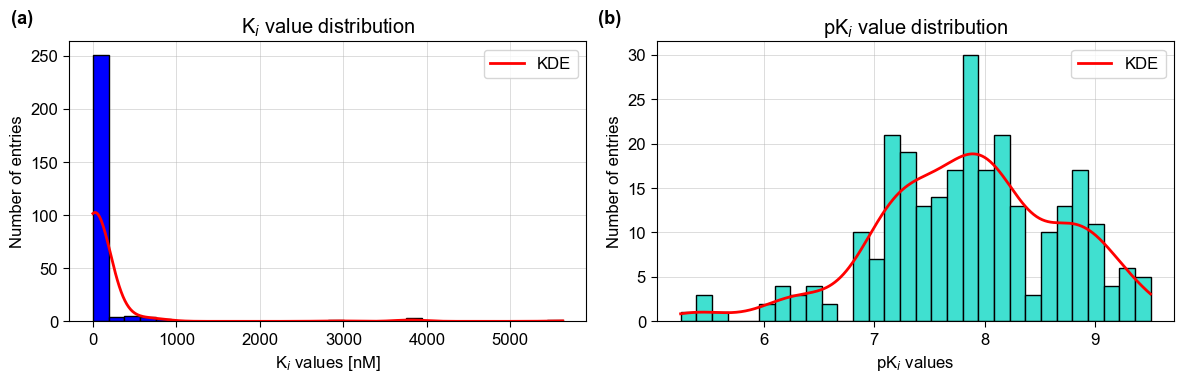

In [51]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# Plot 1: Ki values
data_ki = data["value"]
counts_ki, bins_ki, _ = axes[0].hist(data_ki, bins=30, color='Blue', edgecolor='black')
axes[0].set_title('K$_{i}$ value distribution')
axes[0].set_xlabel('K$_{i}$ values [nM]')
axes[0].set_ylabel('Number of entries')
axes[0].grid(True)

# KDE passend zur Histogramm-Skala
kde_ki = gaussian_kde(data_ki)
x_ki = np.linspace(data_ki.min(), data_ki.max(), 500)
bin_width_ki = bins_ki[1] - bins_ki[0]
axes[0].plot(x_ki, kde_ki(x_ki) * len(data_ki) * bin_width_ki, color="red", lw=2, label="KDE")
axes[0].legend(loc="upper right")

# Plot 2: pKi values
data_pki = data["value_pKi"]
counts_pki, bins_pki, _ = axes[1].hist(data_pki, bins=30, color='Turquoise', edgecolor='black')
axes[1].set_title('pK$_{i}$ value distribution')
axes[1].set_xlabel('pK$_{i}$ values')
axes[1].set_ylabel('Number of entries')
axes[1].grid(True)

# KDE passend zur Histogramm-Skala
kde_pki = gaussian_kde(data_pki)
x_pki = np.linspace(data_pki.min(), data_pki.max(), 500)
bin_width_pki = bins_pki[1] - bins_pki[0]
axes[1].plot(x_pki, kde_pki(x_pki) * len(data_pki) * bin_width_pki, color="red", lw=2, label="KDE")
axes[1].legend(loc="upper right")

# Adjust positions relative to axes (negative y puts it slightly above the plot)
axes[0].text(-0.07, 1.05, "(a)", transform=axes[0].transAxes,
             fontsize=13, fontweight="bold", va="bottom", ha="right")
axes[1].text(-0.07, 1.05, "(b)", transform=axes[1].transAxes,
             fontsize=13, fontweight="bold", va="bottom", ha="right")

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.6)

# Layout anpassen
plt.tight_layout()

# Save & show
plt.savefig("Histogram_Ki_and_pKi_with_KDE.png", dpi=300)
plt.show()

## QQ plot

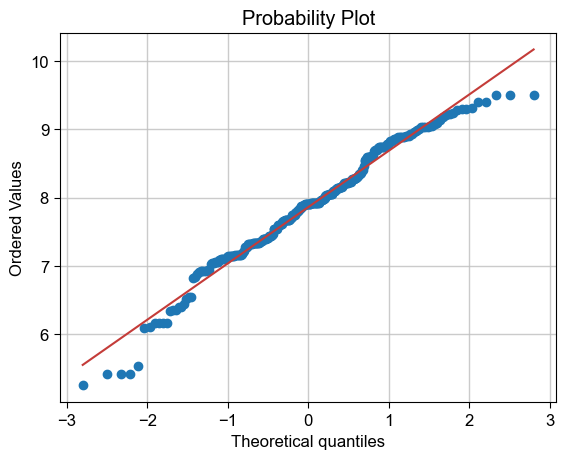

In [52]:
stats.probplot(data["value_pKi"], dist="norm", plot=pylab)
plt.grid(True, color="#bfbfbf", linewidth=1, alpha=0.8)   # grid
plt.gca().lines[0].set_color("#1f77b4")                   # darker blue points
plt.gca().set_axisbelow(True)                             # grid behind points
plt.gca().lines[1].set_color("#c43c39")      # red fitted line (same style as example)
plt.savefig("QQ_plot_dataset_pKi.png", dpi=300)
pylab.show()

# LMM 

## LMM mit Multiple Imputation

In [76]:
# ============================================================
# Linear Mixed Model (LMM) for CB1 pKi
# with Multiple Imputation (MI) for numeric + categorical assay parameters
# ------------------------------------------------------------
# - Response: value_pKi
# - Fixed effects:
#     receptor_species
#     reference_substance
#     cell_cleaned
#     incubation_time
#     temp
#     log10_concentration_radioligand_nM
# - Random effect:
#     random intercept for pubchem_cid
# - Multiple imputation:
#     approximate MICE-style approach using IterativeImputer with posterior draws
# ============================================================


warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------
df_raw = data.copy()

Y_VAR = "value_pKi"
GROUP_VAR = "pubchem_cid"

CATEGORICAL_VARS = ["receptor_species", "reference_substance", "cell_cleaned"]
NUMERIC_VARS_RAW = ["incubation_time", "temp", "concentration radioligand (nM)"]

MI_M = 20
MI_MAX_ITER = 30
MI_RANDOM_SEED = 42

USE_REML_FINAL = True
FIT_NULL_MODEL = True  # useful for ICC / baseline variance structure

REFERENCE_LEVELS = {
    "receptor_species": "human",
    "reference_substance": "3HCP55940",  # robust match to observed spelling
    "cell_cleaned": "hek",
}

# ------------------------------------------------------------
# 1) HELPERS
# ------------------------------------------------------------
def make_safe(name: str) -> str:
    safe = re.sub(r"[^0-9a-zA-Z_]", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = "v_" + safe
    return re.sub(r"_+", "_", safe).strip("_")

def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

def match_reference_level(observed_values, desired_label):
    for v in observed_values:
        if norm_label(v) == norm_label(desired_label):
            return v
    return desired_label

def rubin_pool_scalar(estimates, ses):
    """
    Rubin pooling for one scalar parameter across m imputations.
    Returns pooled estimate, pooled SE, z, p, within-var, between-var.
    """
    q = np.asarray(estimates, dtype=float)
    u = np.asarray(ses, dtype=float) ** 2
    m = len(q)

    qbar = q.mean()
    ubar = u.mean()
    b = q.var(ddof=1) if m > 1 else 0.0
    t = ubar + (1 + 1/m) * b
    se = np.sqrt(t)

    z = qbar / se if se > 0 else np.nan
    p = 2 * norm.sf(abs(z)) if np.isfinite(z) else np.nan

    return qbar, se, z, p, ubar, b

def pool_fixed_effects(fe_params_list, fe_cov_list):
    """
    Rubin pooling for fixed effects only.
    Uses large-sample normal approximation for p-values.
    """
    coef_names = fe_params_list[0].index.tolist()
    rows = []

    for name in coef_names:
        ests = [p[name] for p in fe_params_list]
        ses = [np.sqrt(c.loc[name, name]) for c in fe_cov_list]

        qbar, se, z, p, ubar, b = rubin_pool_scalar(ests, ses)

        rows.append({
            "term": name,
            "estimate": qbar,
            "std_error": se,
            "z_approx": z,
            "p_value_approx": p,
            "ci_low_95": qbar - 1.96 * se,
            "ci_high_95": qbar + 1.96 * se,
            "within_var": ubar,
            "between_var": b
        })

    return pd.DataFrame(rows)

def extract_variance_summary(res_list):
    rows = []
    for i, res in enumerate(res_list, start=1):
        group_var = float(res.cov_re.iloc[0, 0]) if hasattr(res, "cov_re") else np.nan
        resid_var = float(res.scale)
        icc = group_var / (group_var + resid_var) if (group_var + resid_var) > 0 else np.nan

        rows.append({
            "imp": i,
            "group_var": group_var,
            "residual_var": resid_var,
            "ICC": icc
        })
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 2) CLEAN + PREP BASE DATA
# ------------------------------------------------------------
needed_cols = [Y_VAR, GROUP_VAR] + CATEGORICAL_VARS + NUMERIC_VARS_RAW
missing_needed = [c for c in needed_cols if c not in df_raw.columns]
if missing_needed:
    raise ValueError(f"Missing required columns: {missing_needed}")

df = df_raw[needed_cols].copy()
df = df.dropna(subset=[Y_VAR, GROUP_VAR]).copy()

# rename to safe column names
rename_cols = {c: make_safe(c) for c in df.columns}
df = df.rename(columns=rename_cols)

Y = make_safe(Y_VAR)
GROUP = make_safe(GROUP_VAR)

CATS = [make_safe(c) for c in CATEGORICAL_VARS]
NUMS_RAW_SAFE = [make_safe(c) for c in NUMERIC_VARS_RAW]

cat_map = dict(zip(CATEGORICAL_VARS, CATS))
num_raw_map = dict(zip(NUMERIC_VARS_RAW, NUMS_RAW_SAFE))

# categorical cleaning: use object/category, NOT pandas string dtype
for c in CATS:
    df[c] = df[c].astype("object")
    df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())

# group variable
df[GROUP] = df[GROUP].astype("object")
df[GROUP] = df[GROUP].where(df[GROUP].isna(), df[GROUP].astype(str).str.strip())

# numeric coercion
for c in NUMS_RAW_SAFE:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# create log10 radioligand concentration (<=0 -> NaN)
rad_col = make_safe("concentration radioligand (nM)")
df["log10_concentration_radioligand_nM"] = df[rad_col].where(df[rad_col] > 0, np.nan)
df["log10_concentration_radioligand_nM"] = np.log10(df["log10_concentration_radioligand_nM"])

NUMS = [make_safe("incubation_time"), make_safe("temp"), "log10_concentration_radioligand_nM"]

# robustly matched reference levels
observed_reference_levels = {}
for orig_name, safe_name in cat_map.items():
    observed = df[safe_name].dropna().astype(str).unique().tolist()
    desired = REFERENCE_LEVELS[orig_name]
    matched = match_reference_level(observed, desired)
    observed_reference_levels[safe_name] = matched

print("Matched reference levels:")
for k, v in observed_reference_levels.items():
    print(f"  {k}: {v}")

# ------------------------------------------------------------
# 3) BUILD IMPUTATION MATRIX
# ------------------------------------------------------------
base_df = df[[Y, GROUP] + CATS + NUMS].copy()

missing_masks_numeric = {c: base_df[c].isna().copy() for c in NUMS}
missing_masks_categorical = {c: base_df[c].isna().copy() for c in CATS}

cat_levels = {}
cat_dummy_cols = {}

for c in CATS:
    levels = sorted(base_df[c].dropna().astype(str).unique().tolist())
    cat_levels[c] = levels

    dummies = pd.get_dummies(base_df[c], prefix=c, dtype=float)

    # important: rows with missing original category -> all dummy cols = NaN
    miss = base_df[c].isna()
    if dummies.shape[1] > 0:
        dummies.loc[miss, :] = np.nan

    cat_dummy_cols[c] = dummies.columns.tolist()
    base_df = pd.concat([base_df, dummies], axis=1)

# group dummies as auxiliary predictors only
group_dummies = pd.get_dummies(base_df[GROUP].astype(str), prefix="grp", dtype=float)
base_df = pd.concat([base_df, group_dummies], axis=1)

cat_dummy_all = [col for cols in cat_dummy_cols.values() for col in cols]
aux_cols = [Y] + group_dummies.columns.tolist()
imputation_cols = NUMS + cat_dummy_all + aux_cols

imp_df = base_df[imputation_cols].copy()

print("\nMissing values before MI:")
for c in NUMS:
    print(f"  numeric {c}: {int(missing_masks_numeric[c].sum())}")
for c in CATS:
    print(f"  categorical {c}: {int(missing_masks_categorical[c].sum())}")

# ------------------------------------------------------------
# 4) FIT IMPUTER
# ------------------------------------------------------------
imputer = IterativeImputer(
    max_iter=MI_MAX_ITER,
    sample_posterior=True,
    random_state=MI_RANDOM_SEED,
    skip_complete=False
)

imputer.fit(imp_df)

# ------------------------------------------------------------
# 5) MULTIPLE IMPUTATION DIAGNOSTICS
# ------------------------------------------------------------
def mi_diagnostics(imputer, imp_df, num_cols, cat_cols, cat_dummy_cols, base_df, n_draws=5):
    """
    Per-variable MI diagnostics.

    Numeric:
      - mean SD across imputations on originally missing cells

    Categorical:
      - share of rows whose imputed category changes across repeated draws
    """
    diagnostics = []
    draws = []

    for _ in range(n_draws):
        arr = imputer.transform(imp_df)
        draws.append(pd.DataFrame(arr, columns=imp_df.columns, index=imp_df.index))

    # numeric diagnostics
    for c in num_cols:
        miss = base_df[c].isna()
        n_missing = int(miss.sum())

        if n_missing == 0:
            diagnostics.append({
                "variable": c,
                "type": "numeric",
                "n_missing": 0,
                "metric": "no missing values",
                "value": np.nan
            })
            continue

        mat = np.column_stack([d.loc[miss, c].to_numpy() for d in draws])
        mean_sd = np.std(mat, axis=1, ddof=1).mean() if mat.shape[1] > 1 else 0.0

        diagnostics.append({
            "variable": c,
            "type": "numeric",
            "n_missing": n_missing,
            "metric": "mean SD across imputations",
            "value": float(mean_sd)
        })

    # categorical diagnostics
    for c in cat_cols:
        miss = base_df[c].isna()
        n_missing = int(miss.sum())

        if n_missing == 0:
            diagnostics.append({
                "variable": c,
                "type": "categorical",
                "n_missing": 0,
                "metric": "no missing values",
                "value": np.nan
            })
            continue

        cols = cat_dummy_cols[c]
        if len(cols) == 0:
            diagnostics.append({
                "variable": c,
                "type": "categorical",
                "n_missing": n_missing,
                "metric": "no dummy columns",
                "value": np.nan
            })
            continue

        cat_draws = []
        for d in draws:
            block = d.loc[miss, cols].copy()
            chosen = block.idxmax(axis=1).str.replace(f"{c}_", "", regex=False)
            cat_draws.append(chosen)

        cat_draws_df = pd.concat(cat_draws, axis=1)
        n_unique = cat_draws_df.nunique(axis=1)
        instability = (n_unique > 1).mean()

        diagnostics.append({
            "variable": c,
            "type": "categorical",
            "n_missing": n_missing,
            "metric": "share rows changing category across imputations",
            "value": float(instability)
        })

    return pd.DataFrame(diagnostics)

diag_df = mi_diagnostics(
    imputer=imputer,
    imp_df=imp_df,
    num_cols=NUMS,
    cat_cols=CATS,
    cat_dummy_cols=cat_dummy_cols,
    base_df=base_df,
    n_draws=5
)

print("\nMI diagnostics per variable:")
print(diag_df.to_string(index=False))

# ------------------------------------------------------------
# 6) CREATE ONE IMPUTED DATASET
# ------------------------------------------------------------
def create_one_imputed_dataset(base_df, imp_df, imputer, cats, nums, cat_dummy_cols, y_col, group_col):
    arr = imputer.transform(imp_df)
    imp_complete = pd.DataFrame(arr, columns=imp_df.columns, index=imp_df.index)

    out = base_df[[y_col, group_col] + cats + nums].copy()

    # numeric vars: replace only missing values
    for c in nums:
        miss = out[c].isna()
        out.loc[miss, c] = imp_complete.loc[miss, c]

    # categorical vars: reconstruct from imputed dummy block
    for c in cats:
        miss = out[c].isna()
        cols = cat_dummy_cols[c]

        if len(cols) == 0:
            continue

        chosen = imp_complete.loc[miss, cols].idxmax(axis=1).str.replace(f"{c}_", "", regex=False)
        out.loc[miss, c] = chosen.values

        out[c] = out[c].where(out[c].isna(), out[c].astype(str).str.strip())
        out[c] = out[c].astype("category")

    # group as category for statsmodels
    out[group_col] = out[group_col].where(out[group_col].isna(), out[group_col].astype(str).str.strip())
    out[group_col] = out[group_col].astype("category")

    return out

# ------------------------------------------------------------
# 7) DEFINE MODEL FORMULAS
# ------------------------------------------------------------
species_var = make_safe("receptor_species")
reference_substance_var = make_safe("reference_substance")
cell_var = make_safe("cell_cleaned")
time_var = make_safe("incubation_time")
temp_var = make_safe("temp")

species_ref = observed_reference_levels[species_var]
reference_substance_ref = observed_reference_levels[reference_substance_var]
cell_ref = observed_reference_levels[cell_var]

formula_fixed = (
    f"{Y} ~ "
    f"C({species_var}, Treatment(reference={repr(species_ref)})) + "
    f"C({reference_substance_var}, Treatment(reference={repr(reference_substance_ref)})) + "
    f"C({cell_var}, Treatment(reference={repr(cell_ref)})) + "
    f"{time_var} + "
    f"{temp_var} + "
    f"log10_concentration_radioligand_nM"
)

formula_null = f"{Y} ~ 1"

print("\nModel formulas:")
print("NULL :", formula_null, f"+ (1 | {GROUP})")
print("FULL :", formula_fixed, f"+ (1 | {GROUP})")

# ------------------------------------------------------------
# 8) FIT LMM ACROSS IMPUTED DATASETS
# ------------------------------------------------------------
def fit_mixedlm_safe(formula, data, group_col, reml=True):
    data = data.copy()

    # make sure patsy/statsmodels gets category dtype
    for c in [species_var, reference_substance_var, cell_var]:
        data[c] = data[c].astype("category")
    data[group_col] = data[group_col].astype("category")

    model = smf.mixedlm(formula, data=data, groups=data[group_col])

    errors = []
    for method in ["lbfgs", "powell", "nm"]:
        try:
            res = model.fit(reml=reml, method=method, disp=False)
            return res
        except Exception as e:
            errors.append((method, str(e)))

    raise RuntimeError(f"MixedLM failed for all optimizers: {errors}")

full_results = []
null_results = []

for m_idx in range(MI_M):
    df_imp = create_one_imputed_dataset(
        base_df=base_df,
        imp_df=imp_df,
        imputer=imputer,
        cats=CATS,
        nums=NUMS,
        cat_dummy_cols=cat_dummy_cols,
        y_col=Y,
        group_col=GROUP
    )

    # full model
    res_full = fit_mixedlm_safe(formula_fixed, df_imp, GROUP, reml=USE_REML_FINAL)
    full_results.append(res_full)

    # null model
    if FIT_NULL_MODEL:
        res_null = fit_mixedlm_safe(formula_null, df_imp, GROUP, reml=USE_REML_FINAL)
        null_results.append(res_null)

print(f"\nSuccessfully fitted {len(full_results)} imputed full models.")

# ------------------------------------------------------------
# 9) POOL FIXED EFFECTS (Rubin)
# ------------------------------------------------------------
fe_params_list = []
fe_cov_list = []

for res in full_results:
    fe_names = res.fe_params.index.tolist()
    fe_params = res.fe_params.copy()
    fe_cov = res.cov_params().loc[fe_names, fe_names].copy()

    fe_params_list.append(fe_params)
    fe_cov_list.append(fe_cov)

pooled_fixed = pool_fixed_effects(fe_params_list, fe_cov_list)

print("\nPooled fixed effects (Rubin; large-sample normal approximation):")
print(pooled_fixed.to_string(index=False))

# ------------------------------------------------------------
# 10) VARIANCE SUMMARY / ICC
# ------------------------------------------------------------
full_var_df = extract_variance_summary(full_results)

print("\nVariance summary across imputations (full model):")
print(full_var_df[["group_var", "residual_var", "ICC"]].agg(["mean", "median", "min", "max"]).to_string())

# ------------------------------------------------------------
# 11) NULL MODEL ICC SUMMARY
# ------------------------------------------------------------
if FIT_NULL_MODEL and len(null_results) > 0:
    null_var_df = extract_variance_summary(null_results)

    print("\nVariance summary across imputations (null model):")
    print(null_var_df[["group_var", "residual_var", "ICC"]].agg(["mean", "median", "min", "max"]).to_string())

# ------------------------------------------------------------
# 12) EXAMPLE MODEL SUMMARY
# ------------------------------------------------------------
print("\nExample full-model summary from imputation 1:")
print(full_results[0].summary())

# ------------------------------------------------------------
# 13) EXPORT RESULTS TO EXCEL
# ------------------------------------------------------------
output_file = "LMM_pKi_MI_results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    pooled_fixed.to_excel(writer, sheet_name="pooled_fixed_effects", index=False)
    diag_df.to_excel(writer, sheet_name="mi_diagnostics", index=False)
    full_var_df.to_excel(writer, sheet_name="full_model_variance", index=False)

    if FIT_NULL_MODEL and len(null_results) > 0:
        null_var_df.to_excel(writer, sheet_name="null_model_variance", index=False)

    # fixed effects from first imputation
    fe_names = full_results[0].fe_params.index.tolist()
    imp1_coef_df = pd.DataFrame({
        "term": fe_names,
        "estimate": full_results[0].fe_params.values,
        "std_error": full_results[0].bse_fe.values,
        "z_value": full_results[0].tvalues[fe_names].values,
        "p_value": full_results[0].pvalues[fe_names].values,
        "ci_low_95": full_results[0].conf_int().loc[fe_names, 0].values,
        "ci_high_95": full_results[0].conf_int().loc[fe_names, 1].values,
    })
    imp1_coef_df.to_excel(writer, sheet_name="imputation1_fixed_effects", index=False)

    # random-effect variance summary from imputation 1
    imp1_var_df = pd.DataFrame({
        "metric": ["group_var", "residual_var", "ICC"],
        "value": [
            float(full_results[0].cov_re.iloc[0, 0]),
            float(full_results[0].scale),
            float(full_results[0].cov_re.iloc[0, 0]) / (
                float(full_results[0].cov_re.iloc[0, 0]) + float(full_results[0].scale)
            )
        ]
    })
    imp1_var_df.to_excel(writer, sheet_name="imputation1_variance", index=False)

print(f"Excel file saved: {output_file}")

Matched reference levels:
  receptor_species: human
  reference_substance: [3H]CP-55940
  cell_cleaned: hek

Missing values before MI:
  numeric incubation_time: 43
  numeric temp: 78
  numeric log10_concentration_radioligand_nM: 64
  categorical receptor_species: 2
  categorical reference_substance: 1
  categorical cell_cleaned: 12

MI diagnostics per variable:
                          variable        type  n_missing                                          metric     value
                   incubation_time     numeric         43                      mean SD across imputations 32.848003
                              temp     numeric         78                      mean SD across imputations 11.390264
log10_concentration_radioligand_nM     numeric         64                      mean SD across imputations  0.859062
                  receptor_species categorical          2 share rows changing category across imputations  1.000000
               reference_substance categorical         

## LMM without multiple impuation (complete-case-version)


In [77]:
# ============================================================
# Linear Mixed Model (LMM) for CB1 pKi
# COMPLETE-CASE ANALYSIS (no imputation)
# ------------------------------------------------------------
# - Response: value_pKi
# - Fixed effects:
#     receptor_species
#     reference_substance
#     cell_cleaned
#     incubation_time
#     temp
#     log10_concentration_radioligand_nM
# - Random effect:
#     random intercept for pubchem_cid
# - Missing data handling:
#     complete-case only
# ============================================================



warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------------------
# 0) CONFIG
# ------------------------------------------------------------
df_raw = data.copy()

Y_VAR = "value_pKi"
GROUP_VAR = "pubchem_cid"

CATEGORICAL_VARS = ["receptor_species", "reference_substance", "cell_cleaned"]
NUMERIC_VARS_RAW = ["incubation_time", "temp", "concentration radioligand (nM)"]

USE_REML_FINAL = True
FIT_NULL_MODEL = True

REFERENCE_LEVELS = {
    "receptor_species": "human",
    "reference_substance": "3HCP55940",
    "cell_cleaned": "hek",
}

# ------------------------------------------------------------
# 1) HELPERS
# ------------------------------------------------------------
def make_safe(name: str) -> str:
    safe = re.sub(r"[^0-9a-zA-Z_]", "_", str(name))
    if re.match(r"^[0-9]", safe):
        safe = "v_" + safe
    return re.sub(r"_+", "_", safe).strip("_")

def norm_label(x: str) -> str:
    return re.sub(r"[^0-9A-Za-z]+", "", str(x)).lower()

def match_reference_level(observed_values, desired_label):
    for v in observed_values:
        if norm_label(v) == norm_label(desired_label):
            return v
    return desired_label

def extract_variance_summary_one(res):
    group_var = float(res.cov_re.iloc[0, 0]) if hasattr(res, "cov_re") else np.nan
    residual_var = float(res.scale)
    icc = group_var / (group_var + residual_var) if (group_var + residual_var) > 0 else np.nan
    return {
        "group_var": group_var,
        "residual_var": residual_var,
        "ICC": icc
    }

def fit_mixedlm_safe(formula, data, group_col, categorical_cols, reml=True):
    data = data.copy()

    for c in categorical_cols:
        data[c] = data[c].astype("category")
    data[group_col] = data[group_col].astype("category")

    model = smf.mixedlm(formula, data=data, groups=data[group_col])

    errors = []
    for method in ["lbfgs", "powell", "nm"]:
        try:
            res = model.fit(reml=reml, method=method, disp=False)
            return res
        except Exception as e:
            errors.append((method, str(e)))

    raise RuntimeError(f"MixedLM failed for all optimizers: {errors}")

# ------------------------------------------------------------
# 2) CLEAN + PREP DATA
# ------------------------------------------------------------
needed_cols = [Y_VAR, GROUP_VAR] + CATEGORICAL_VARS + NUMERIC_VARS_RAW
missing_needed = [c for c in needed_cols if c not in df_raw.columns]
if missing_needed:
    raise ValueError(f"Missing required columns: {missing_needed}")

df = df_raw[needed_cols].copy()

# keep only rows with observed response and observed group
df = df.dropna(subset=[Y_VAR, GROUP_VAR]).copy()

# rename to safe column names
rename_cols = {c: make_safe(c) for c in df.columns}
df = df.rename(columns=rename_cols)

Y = make_safe(Y_VAR)
GROUP = make_safe(GROUP_VAR)

species_var = make_safe("receptor_species")
reference_substance_var = make_safe("reference_substance")
cell_var = make_safe("cell_cleaned")
time_var = make_safe("incubation_time")
temp_var = make_safe("temp")
rad_raw_var = make_safe("concentration radioligand (nM)")

CATS = [species_var, reference_substance_var, cell_var]
NUMS_RAW_SAFE = [time_var, temp_var, rad_raw_var]

# categorical cleaning
for c in CATS:
    df[c] = df[c].astype("object")
    df[c] = df[c].where(df[c].isna(), df[c].astype(str).str.strip())

# group variable
df[GROUP] = df[GROUP].astype("object")
df[GROUP] = df[GROUP].where(df[GROUP].isna(), df[GROUP].astype(str).str.strip())

# numeric coercion
for c in NUMS_RAW_SAFE:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# create log10 radioligand concentration (<=0 -> NaN)
df["log10_concentration_radioligand_nM"] = df[rad_raw_var].where(df[rad_raw_var] > 0, np.nan)
df["log10_concentration_radioligand_nM"] = np.log10(df["log10_concentration_radioligand_nM"])

# match reference levels based on observed data before complete-case filtering
observed_reference_levels = {}
for orig_name, safe_name in zip(CATEGORICAL_VARS, CATS):
    observed = df[safe_name].dropna().astype(str).unique().tolist()
    desired = REFERENCE_LEVELS[orig_name]
    matched = match_reference_level(observed, desired)
    observed_reference_levels[safe_name] = matched

print("Matched reference levels:")
for k, v in observed_reference_levels.items():
    print(f"  {k}: {v}")

# ------------------------------------------------------------
# 3) COMPLETE-CASE FILTER
# ------------------------------------------------------------
model_vars = [
    Y, GROUP,
    species_var, reference_substance_var, cell_var,
    time_var, temp_var, "log10_concentration_radioligand_nM"
]

df_cc = df[model_vars].copy()

n_before = len(df_cc)
df_cc = df_cc.dropna().copy()
n_after = len(df_cc)
n_dropped = n_before - n_after

print("\nComplete-case filtering:")
print(f"  Rows before complete-case filter: {n_before}")
print(f"  Rows after complete-case filter : {n_after}")
print(f"  Rows dropped                    : {n_dropped}")

print("\nComplete-case group sizes:")
print(df_cc[GROUP].value_counts().sort_index().to_string())

# ------------------------------------------------------------
# 4) DEFINE MODEL FORMULAS
# ------------------------------------------------------------
species_ref = observed_reference_levels[species_var]
reference_substance_ref = observed_reference_levels[reference_substance_var]
cell_ref = observed_reference_levels[cell_var]

formula_fixed = (
    f"{Y} ~ "
    f"C({species_var}, Treatment(reference={repr(species_ref)})) + "
    f"C({reference_substance_var}, Treatment(reference={repr(reference_substance_ref)})) + "
    f"C({cell_var}, Treatment(reference={repr(cell_ref)})) + "
    f"{time_var} + "
    f"{temp_var} + "
    f"log10_concentration_radioligand_nM"
)

formula_null = f"{Y} ~ 1"

print("\nModel formulas:")
print("NULL :", formula_null, f"+ (1 | {GROUP})")
print("FULL :", formula_fixed, f"+ (1 | {GROUP})")

# ------------------------------------------------------------
# 5) FIT COMPLETE-CASE MODELS
# ------------------------------------------------------------
res_full_cc = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_cc,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

if FIT_NULL_MODEL:
    res_null_cc = fit_mixedlm_safe(
        formula=formula_null,
        data=df_cc,
        group_col=GROUP,
        categorical_cols=CATS,
        reml=USE_REML_FINAL
    )
else:
    res_null_cc = None

print("\nComplete-case full model fitted successfully.")
if FIT_NULL_MODEL:
    print("Complete-case null model fitted successfully.")

# ------------------------------------------------------------
# 6) FIXED EFFECTS TABLE
# ------------------------------------------------------------
full_summary_table = pd.DataFrame({
    "term": res_full_cc.fe_params.index,
    "estimate": res_full_cc.fe_params.values,
    "std_error": res_full_cc.bse_fe.values,
    "z_value": res_full_cc.fe_params.values / res_full_cc.bse_fe.values,
    "p_value": res_full_cc.pvalues.loc[res_full_cc.fe_params.index].values,
    "ci_low_95": res_full_cc.conf_int().loc[res_full_cc.fe_params.index, 0].values,
    "ci_high_95": res_full_cc.conf_int().loc[res_full_cc.fe_params.index, 1].values
})

print("\nComplete-case fixed effects:")
print(full_summary_table.to_string(index=False))

# ------------------------------------------------------------
# 7) VARIANCE SUMMARY / ICC
# ------------------------------------------------------------
full_var_cc = extract_variance_summary_one(res_full_cc)

print("\nComplete-case variance summary (full model):")
for k, v in full_var_cc.items():
    print(f"  {k}: {v:.6f}")

if res_null_cc is not None:
    null_var_cc = extract_variance_summary_one(res_null_cc)

    print("\nComplete-case variance summary (null model):")
    for k, v in null_var_cc.items():
        print(f"  {k}: {v:.6f}")

# ------------------------------------------------------------
# 8) MODEL SUMMARIES
# ------------------------------------------------------------
print("\nComplete-case FULL model summary:")
print(res_full_cc.summary())

if res_null_cc is not None:
    print("\nComplete-case NULL model summary:")
    print(res_null_cc.summary())


# ------------------------------------------------------------
# 9) EXPORT COMPLETE-CASE LMM RESULTS TO EXCEL
# ------------------------------------------------------------
output_file_cc = "LMM_pKi_complete_case_results.xlsx"

with pd.ExcelWriter(output_file_cc, engine="openpyxl") as writer:
    # fixed effects
    full_summary_table.to_excel(writer, sheet_name="fixed_effects", index=False)

    # variance summaries
    pd.DataFrame([full_var_cc]).to_excel(writer, sheet_name="full_model_variance", index=False)

    if res_null_cc is not None:
        pd.DataFrame([null_var_cc]).to_excel(writer, sheet_name="null_model_variance", index=False)

    # complete-case sample information
    cc_info_df = pd.DataFrame({
        "metric": [
            "rows_before_complete_case_filter",
            "rows_after_complete_case_filter",
            "rows_dropped"
        ],
        "value": [n_before, n_after, n_dropped]
    })
    cc_info_df.to_excel(writer, sheet_name="complete_case_info", index=False)

    # group sizes after complete-case filtering
    group_sizes_cc_df = (
        df_cc[GROUP]
        .value_counts()
        .sort_index()
        .rename_axis("pubchem_cid")
        .reset_index(name="n_rows")
    )
    group_sizes_cc_df.to_excel(writer, sheet_name="group_sizes_complete_case", index=False)

    # reference levels used
    ref_levels_df = pd.DataFrame({
        "variable": list(observed_reference_levels.keys()),
        "reference_level": list(observed_reference_levels.values())
    })
    ref_levels_df.to_excel(writer, sheet_name="reference_levels", index=False)

print(f"Excel file saved: {output_file_cc}")


Matched reference levels:
  receptor_species: human
  reference_substance: [3H]CP-55940
  cell_cleaned: hek

Complete-case filtering:
  Rows before complete-case filter: 271
  Rows after complete-case filter : 162
  Rows dropped                    : 109

Complete-case group sizes:
pubchem_cid
10382701     8
104850      38
104895      23
16078       20
3081355      8
44208932     5
5281969     14
5311501     37
638026       5
6918505      4

Model formulas:
NULL : value_pKi ~ 1 + (1 | pubchem_cid)
FULL : value_pKi ~ C(receptor_species, Treatment(reference='human')) + C(reference_substance, Treatment(reference='[3H]CP-55940')) + C(cell_cleaned, Treatment(reference='hek')) + incubation_time + temp + log10_concentration_radioligand_nM + (1 | pubchem_cid)

Complete-case full model fitted successfully.
Complete-case null model fitted successfully.

Complete-case fixed effects:
                                                                          term  estimate  std_error   z_value       

## Diagnostics

based on multiple imputation model

In [78]:
# ============================================================
# SHARED MODEL OBJECTS FOR DIAGNOSTIC FIGURES

# ============================================================

df_imp_1_shared = create_one_imputed_dataset(
    base_df=base_df,
    imp_df=imp_df,
    imputer=imputer,
    cats=CATS,
    nums=NUMS,
    cat_dummy_cols=cat_dummy_cols,
    y_col=Y,
    group_col=GROUP
).copy()

res_imp_1_shared = fit_mixedlm_safe(
    formula=formula_fixed,
    data=df_imp_1_shared,
    group_col=GROUP,
    categorical_cols=CATS,
    reml=USE_REML_FINAL
)

# shared observed, fitted, residuals
observed_1 = df_imp_1_shared[Y].astype(float)
fitted_1 = res_imp_1_shared.fittedvalues.astype(float)
residuals_1 = res_imp_1_shared.resid.astype(float)

resid_sd_1 = np.sqrt(res_imp_1_shared.scale)
std_residuals_1 = residuals_1 / resid_sd_1

### Observed vs Predicted pKᵢ

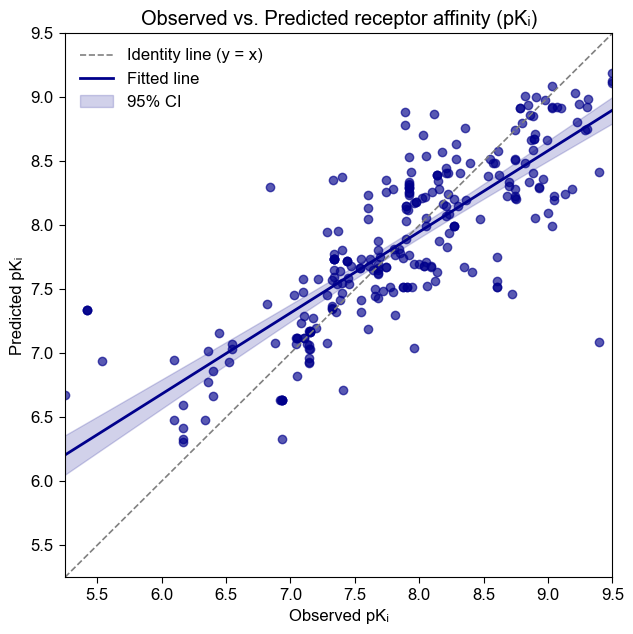

Correlation observed vs predicted: 0.804
RMSE: 0.491
                            OLS Regression Results                            
Dep. Variable:              predicted   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     493.0
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           9.04e-63
Time:                        13:30:47   Log-Likelihood:                -127.15
No. Observations:                 271   AIC:                             258.3
Df Residuals:                     269   BIC:                             265.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [79]:
# ============================================================
# Observed vs Predicted pKᵢ
# using the shared imputed dataset and shared fitted model
# ============================================================

plot_df = pd.DataFrame({
    "observed": observed_1.values,
    "predicted": fitted_1.values
}).dropna().copy()

X = sm.add_constant(plot_df["observed"])
ols_line = sm.OLS(plot_df["predicted"], X).fit()

x_grid = np.linspace(plot_df["observed"].min(), plot_df["observed"].max(), 200)
X_grid = sm.add_constant(x_grid)
pred_frame = ols_line.get_prediction(X_grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.scatter(
    plot_df["observed"],
    plot_df["predicted"],
    alpha=0.65,
    color="darkblue"
)

xy_min = min(plot_df["observed"].min(), plot_df["predicted"].min())
xy_max = max(plot_df["observed"].max(), plot_df["predicted"].max())

ax.plot(
    [xy_min, xy_max],
    [xy_min, xy_max],
    linestyle="--",
    color="grey",
    linewidth=1.2,
    label="Identity line (y = x)"
)

ax.plot(
    x_grid,
    pred_frame["mean"],
    color="darkblue",
    linewidth=2,
    label="Fitted line"
)

ax.fill_between(
    x_grid,
    pred_frame["mean_ci_lower"].values,
    pred_frame["mean_ci_upper"].values,
    color="darkblue",
    alpha=0.18,
    label="95% CI"
)

ax.set_xlabel("Observed pKᵢ")
ax.set_ylabel("Predicted pKᵢ")
ax.set_title("Observed vs. Predicted receptor affinity (pKᵢ)")

ax.set_xlim(xy_min, xy_max)
ax.set_ylim(xy_min, xy_max)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("Observed_vs_Predicted_pKi_MI_imputation1.tiff", dpi=300, bbox_inches="tight")
plt.show()

corr = np.corrcoef(plot_df["observed"], plot_df["predicted"])[0, 1]
rmse = np.sqrt(np.mean((plot_df["observed"] - plot_df["predicted"])**2))

print(f"Correlation observed vs predicted: {corr:.3f}")
print(f"RMSE: {rmse:.3f}")
print(ols_line.summary())

### Resdiduals vs Fitted

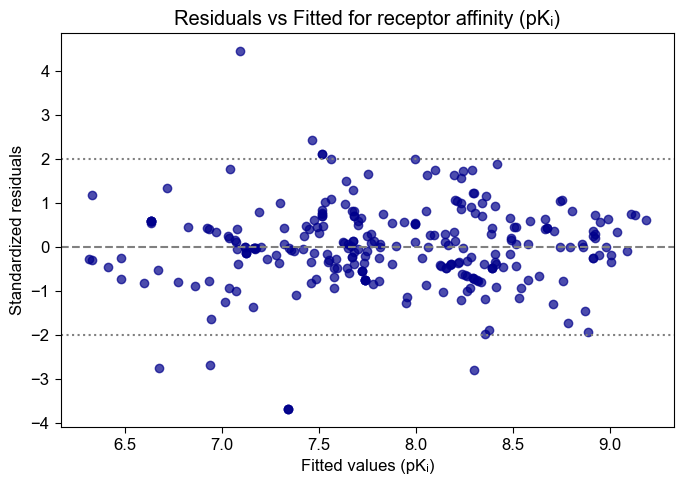

Residual summary:
count    2.710000e+02
mean    -1.386509e-14
std      9.472597e-01
min     -3.696368e+00
25%     -4.892180e-01
50%     -1.525200e-02
75%      5.516176e-01
max      4.441255e+00
dtype: float64


In [80]:
# ============================================================
# Residuals vs Fitted pKᵢ
# using the same shared imputed dataset and shared fitted model
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    fitted_1,
    std_residuals_1,
    alpha=0.7,
    color="darkblue"
)

plt.axhline(0, linestyle="--", color="grey")
plt.axhline(2, linestyle=":", color="grey")
plt.axhline(-2, linestyle=":", color="grey")

plt.xlabel("Fitted values (pKᵢ)")
plt.ylabel("Standardized residuals")
plt.title("Residuals vs Fitted for receptor affinity (pKᵢ)")

plt.tight_layout()
plt.savefig("residuals_vs_fitted_ki.png", dpi=300, bbox_inches="tight")
plt.show()

print("Residual summary:")
print(pd.Series(std_residuals_1).describe())

### Resdiduals  vs Substance

Residual summary by substance:
substance     substance_label  n  mean_std_residual  sd_std_residual  min_std_residual  max_std_residual  median_std_residual
  6918505       JWH-133 (n=6)  6          -0.147277         0.666288         -0.732104          1.163583        -2.892873e-01
   104850   Rimonabant (n=76) 76           0.008010         0.968390         -2.804132          1.996184        -1.032997e-01
    16078       Δ⁹-THC (n=28) 28           0.002593         0.562031         -0.928376          1.486852        -6.518120e-02
   638026        Δ⁸-THC (n=9)  9          -0.023306         0.640052         -1.380867          0.989230        -4.079154e-02
  5281969 CHEMBL381689 (n=28) 28          -0.012714         0.698845         -1.633141          1.773018        -2.332308e-02
 44208932    Anandamide (n=7)  7          -0.053166         2.205793         -2.693721          4.441255        -2.014471e-02
  5311501  WIN55,212-2 (n=63) 63           0.001918         1.151521         -3.696368 

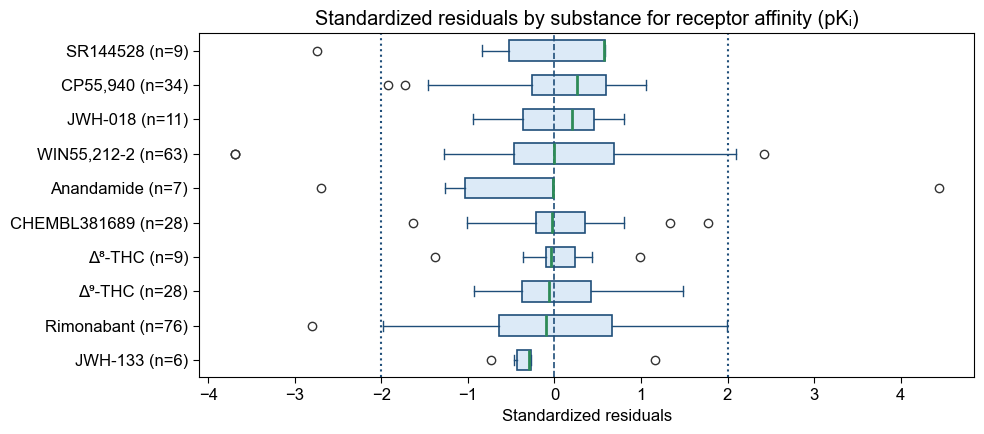

In [81]:
# ============================================================
#  Standardized residuals by substance
# pKi MI-LMM
# using the SAME shared imputed dataset and SAME fitted model
# 
# ============================================================

# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> substance name
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "10382701": "JWH-018",
    "104850": "Rimonabant",
    "5311501": "WIN55,212-2",
    "16078": "Δ⁹-THC",
    "638026": "Δ⁸-THC",
    "5281969": "CHEMBL381689",
    "44208932": "Anandamide",
    "3081355": "SR144528",
    "6918505": "JWH-133",
}

# ------------------------------------------------------------
# 2) use shared dataset + shared fitted model
#    IMPORTANT: run the shared block first
# ------------------------------------------------------------
df_plot = df_imp_1_shared.copy()
res_plot = res_imp_1_shared

# ------------------------------------------------------------
# 3) residuals
# ------------------------------------------------------------
residuals_1 = res_plot.resid.astype(float)
std_residuals_1 = residuals_1 / np.sqrt(res_plot.scale)

# ------------------------------------------------------------
# 4) build diagnostic dataframe
# ------------------------------------------------------------
diag_substance_df = pd.DataFrame({
    "substance": df_plot[GROUP].astype(str).values,
    "residual": residuals_1.values,
    "std_residual": std_residuals_1.values
})

# n per substance
n_df = (
    diag_substance_df.groupby("substance", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)

diag_substance_df = diag_substance_df.merge(n_df, on="substance", how="left")

def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

diag_substance_df["substance_label"] = diag_substance_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# order by median standardized residual
order_df = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(median_std_residual=("std_residual", "median"))
    .sort_values("median_std_residual")
)

ordered_labels = order_df["substance_label"].tolist()

# summary table
substance_summary = (
    diag_substance_df.groupby(["substance", "substance_label"], as_index=False)
    .agg(
        n=("std_residual", "size"),
        mean_std_residual=("std_residual", "mean"),
        sd_std_residual=("std_residual", "std"),
        min_std_residual=("std_residual", "min"),
        max_std_residual=("std_residual", "max"),
        median_std_residual=("std_residual", "median")
    )
    .sort_values("median_std_residual")
)

print("Residual summary by substance:")
print(substance_summary.to_string(index=False))

# ------------------------------------------------------------
# 5) plot settings
# ------------------------------------------------------------
box_face = "#DCEAF7"
box_edge = "#1F4E79"
median_color = "#2E8B57"
whisker_color = "#1F4E79"
cap_color = "#1F4E79"
flier_edge = "#333333"

data_to_plot = [
    diag_substance_df.loc[
        diag_substance_df["substance_label"] == lab,
        "std_residual"
    ].values
    for lab in ordered_labels
]

# ------------------------------------------------------------
# 6) horizontal boxplot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.5))

bp = ax.boxplot(
    data_to_plot,
    vert=False,
    patch_artist=True,
    labels=ordered_labels,
    widths=0.6,
    whis=1.5
)

for box in bp["boxes"]:
    box.set(facecolor=box_face, edgecolor=box_edge, linewidth=1.2)

for whisker in bp["whiskers"]:
    whisker.set(color=whisker_color, linewidth=1.0)

for cap in bp["caps"]:
    cap.set(color=cap_color, linewidth=1.0)

for median in bp["medians"]:
    median.set(color=median_color, linewidth=2.0)

for flier in bp["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="white",
        markeredgecolor=flier_edge,
        markersize=6,
        linestyle="none"
    )

ax.axvline(0, color=box_edge, linestyle="--", linewidth=1.2)
ax.axvline(2, color=box_edge, linestyle=":", linewidth=1.5)
ax.axvline(-2, color=box_edge, linestyle=":", linewidth=1.5)

ax.set_title("Standardized residuals by substance for receptor affinity (pKᵢ)")
ax.set_xlabel("Standardized residuals")
ax.set_ylabel("")
ax.grid(False)

plt.tight_layout()
plt.savefig("standardized_residuals_by_substance_pki.png", dpi=300, bbox_inches="tight")
plt.show()

### Random intercept per substance

Random intercepts by substance:
substance  n  random_intercept               label
  6918505  6         -1.188345       JWH-133 (n=6)
  3081355  9         -0.884767      SR144528 (n=9)
 44208932  7         -0.500481    Anandamide (n=7)
  5281969 28         -0.478744 CHEMBL381689 (n=28)
   638026  9         -0.282079     Δ$^8$-THC (n=9)
    16078 28          0.097625    Δ$^9$-THC (n=28)
  5311501 63          0.162499  WIN55,212-2 (n=63)
   104850 76          0.818614   Rimonabant (n=76)
 10382701 11          0.914742      JWH-018 (n=11)
   104895 34          1.340936     CP55,940 (n=34)


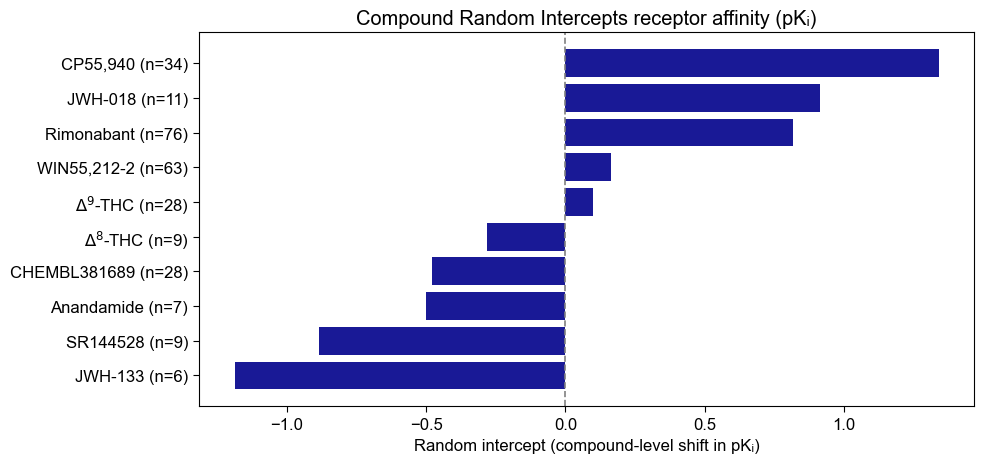

In [82]:
# ============================================================
# DIAGNOSTIC B: Random intercepts by substance
# pKi MI-LMM
# using the SAME shared imputed dataset and SAME fitted model
# ============================================================

# ------------------------------------------------------------
# 1) Mapping pubchem_cid -> substance name
# ------------------------------------------------------------
compound_name_map = {
    "104895": "CP55,940",
    "10382701": "JWH-018",
    "104850": "Rimonabant",
    "5311501": "WIN55,212-2",
    "16078": "Δ$^9$-THC",
    "638026": "Δ$^8$-THC",
    "5281969": "CHEMBL381689",
    "44208932": "Anandamide",
    "3081355": "SR144528",
    "6918505": "JWH-133",
}

# ------------------------------------------------------------
# 2) use shared dataset + shared fitted model
#    IMPORTANT: run the shared block first
# ------------------------------------------------------------
df_plot = df_imp_1_shared.copy()
res_plot = res_imp_1_shared

# ------------------------------------------------------------
# 3) extract random intercepts
# ------------------------------------------------------------
re_dict = res_plot.random_effects

random_intercepts = []

for substance, effect in re_dict.items():
    if hasattr(effect, "iloc"):
        val = float(effect.iloc[0])
    elif isinstance(effect, (list, tuple, np.ndarray)):
        val = float(effect[0])
    else:
        val = float(effect)

    random_intercepts.append({
        "substance": str(substance),
        "random_intercept": val
    })

re_df = pd.DataFrame(random_intercepts)

# ------------------------------------------------------------
# 4) add n per substance from same imputed dataset
# ------------------------------------------------------------
n_df = (
    df_plot.groupby(GROUP, as_index=False)
    .size()
    .rename(columns={GROUP: "substance", "size": "n"})
)

n_df["substance"] = n_df["substance"].astype(str)

re_df = re_df.merge(n_df, on="substance", how="left")

# ------------------------------------------------------------
# 5) build pretty y-axis labels
# ------------------------------------------------------------
def make_substance_label(cid, n):
    pretty_name = compound_name_map.get(str(cid), str(cid))
    return f"{pretty_name} (n={int(n)})"

re_df["label"] = re_df.apply(
    lambda row: make_substance_label(row["substance"], row["n"]),
    axis=1
)

# sort from lowest to highest random intercept
re_df = re_df.sort_values("random_intercept").reset_index(drop=True)

print("Random intercepts by substance:")
print(re_df[["substance", "n", "random_intercept", "label"]].to_string(index=False))

# ------------------------------------------------------------
# 6) plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 4.8))

plt.barh(
    re_df["label"],
    re_df["random_intercept"],
    color="darkblue",
    alpha=0.9
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1.2)

plt.grid(False)

plt.xlabel("Random intercept (compound-level shift in pKᵢ)")
plt.ylabel("")
plt.title("Compound Random Intercepts receptor affinity (pKᵢ)")

plt.tight_layout()
plt.savefig("compound_random_intercept_pki.png", dpi=300, bbox_inches="tight")
plt.show()

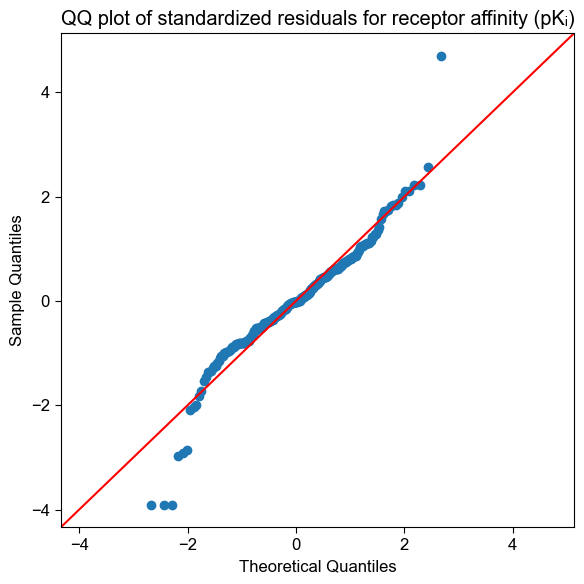

Standardized residual summary:
count    2.710000e+02
mean    -1.386509e-14
std      9.472597e-01
min     -3.696368e+00
25%     -4.892180e-01
50%     -1.525200e-02
75%      5.516176e-01
max      4.441255e+00
dtype: float64


In [83]:
# ============================================================
# DIAGNOSTIC 2: QQ-Plot of residuals
# pKi MI-LMM
# using the SAME shared imputed dataset and SAME fitted model
# ============================================================


res_plot = res_imp_1_shared

# residuals from the shared model
residuals_1 = res_plot.resid.astype(float)
std_residuals_1 = residuals_1 / np.sqrt(res_plot.scale)

# QQ plot
fig = plt.figure(figsize=(6, 6))
sm.qqplot(
    std_residuals_1,
    line="45",
    fit=True,
    ax=plt.gca()
)

plt.title("QQ plot of standardized residuals for receptor affinity (pKᵢ)")
plt.tight_layout()
plt.savefig("qqplot_standardized_residuals_pki.png", dpi=300, bbox_inches="tight")
plt.show()

print("Standardized residual summary:")
print(pd.Series(std_residuals_1).describe())

In [84]:
# ============================================================
# DIAGNOSTIC 3: Leave-one-substance-out sensitivity analysis
# for the MI model
# ============================================================

# ------------------------------------------------------------
# helper: pool fixed effects from a list of fitted models
# ------------------------------------------------------------
def pool_fixed_effects_from_results(results_list):
    fe_params_list = []
    fe_cov_list = []

    for res in results_list:
        fe_names = res.fe_params.index.tolist()
        fe_params = res.fe_params.copy()
        fe_cov = res.cov_params().loc[fe_names, fe_names].copy()

        fe_params_list.append(fe_params)
        fe_cov_list.append(fe_cov)

    return pool_fixed_effects(fe_params_list, fe_cov_list)


# ------------------------------------------------------------
# 1) recreate MI datasets and fit baseline MI models
# ------------------------------------------------------------
mi_datasets = []
mi_results_full = []

for m_idx in range(MI_M):
    df_imp_m = create_one_imputed_dataset(
        base_df=base_df,
        imp_df=imp_df,
        imputer=imputer,
        cats=CATS,
        nums=NUMS,
        cat_dummy_cols=cat_dummy_cols,
        y_col=Y,
        group_col=GROUP
    )
    mi_datasets.append(df_imp_m)

    res_full_m = fit_mixedlm_safe(
        formula=formula_fixed,
        data=df_imp_m,
        group_col=GROUP,
        categorical_cols=CATS,
        reml=USE_REML_FINAL
    )
    mi_results_full.append(res_full_m)

# pooled baseline estimates
pooled_full = pool_fixed_effects_from_results(mi_results_full).copy()
pooled_full = pooled_full.rename(columns={"estimate": "estimate_full"})
pooled_full = pooled_full[["term", "estimate_full"]]

print("Baseline pooled MI model ready.")
print(pooled_full.to_string(index=False))


# ------------------------------------------------------------
# 2) leave-one-substance-out
# ------------------------------------------------------------
substances = sorted(pd.Series(mi_datasets[0][GROUP].astype(str).unique()).tolist())

loo_rows = []
failed_substances = []

for substance in substances:
    loo_results = []

    for df_imp_m in mi_datasets:
        df_loo = df_imp_m[df_imp_m[GROUP].astype(str) != str(substance)].copy()

        # must still have at least 2 groups
        n_groups = df_loo[GROUP].astype(str).nunique()
        if n_groups < 2:
            continue

        try:
            res_loo = fit_mixedlm_safe(
                formula=formula_fixed,
                data=df_loo,
                group_col=GROUP,
                categorical_cols=CATS,
                reml=USE_REML_FINAL
            )
            loo_results.append(res_loo)

        except Exception as e:
            failed_substances.append({
                "left_out_substance": substance,
                "error": str(e)
            })

    # if no successful fits for this substance, skip
    if len(loo_results) == 0:
        continue

    pooled_loo = pool_fixed_effects_from_results(loo_results).copy()
    pooled_loo = pooled_loo.rename(columns={"estimate": "estimate_loo"})
    pooled_loo = pooled_loo[["term", "estimate_loo"]]

    merged = pooled_full.merge(pooled_loo, on="term", how="inner")
    merged["left_out_substance"] = substance
    merged["abs_change"] = (merged["estimate_loo"] - merged["estimate_full"]).abs()

    merged["rel_change_pct"] = np.where(
        merged["estimate_full"].abs() > 1e-8,
        100 * merged["abs_change"] / merged["estimate_full"].abs(),
        np.nan
    )

    loo_rows.append(merged)

if len(loo_rows) == 0:
    raise RuntimeError("No leave-one-substance-out models could be fitted.")

loo_df = pd.concat(loo_rows, ignore_index=True)


# ------------------------------------------------------------
# 3) summarize influence per coefficient
# ------------------------------------------------------------
summary_rows = []

for term, subdf in loo_df.groupby("term"):
    idx_max = subdf["abs_change"].idxmax()

    summary_rows.append({
        "term": term,
        "max_abs_change": subdf["abs_change"].max(),
        "median_abs_change": subdf["abs_change"].median(),
        "worst_case_substance": loo_df.loc[idx_max, "left_out_substance"],
        "baseline_estimate": loo_df.loc[idx_max, "estimate_full"]
    })

loo_summary = pd.DataFrame(summary_rows).sort_values(
    "max_abs_change", ascending=False
)

print("\nLeave-one-substance-out summary:")
print(loo_summary.to_string(index=False))


# ------------------------------------------------------------
# 4) detailed results for selected terms
# ------------------------------------------------------------
key_terms = [
    "Intercept",
    "C(cell_cleaned, Treatment(reference='hek'))[T.cho]",
    "C(cell_cleaned, Treatment(reference='hek'))[T.chem-1]",
    "incubation_time",
    "temp",
    "log10_concentration_radioligand_nM"
]

print("\nDetailed leave-one-substance-out results for selected terms:")
detail_df = loo_df[loo_df["term"].isin(key_terms)].copy()
detail_df = detail_df.sort_values(["term", "abs_change"], ascending=[True, False])
print(detail_df.to_string(index=False))


# ------------------------------------------------------------
# 5) optional: show failed leave-one-out fits
# ------------------------------------------------------------
if len(failed_substances) > 0:
    failed_df = pd.DataFrame(failed_substances).drop_duplicates()
    print("\nLeave-one-substance-out fits with errors:")
    print(failed_df.to_string(index=False))
else:
    print("\nAll leave-one-substance-out fits completed without recorded errors.")

Baseline pooled MI model ready.
                                                                          term  estimate_full
                                                                     Intercept       7.408781
                    C(receptor_species, Treatment(reference='human'))[T.mouse]       0.016944
                      C(receptor_species, Treatment(reference='human'))[T.rat]      -0.033143
       C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.CELT-335]      -0.492455
    C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[125I]AM251]       0.218258
  C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[125I]SD-7015]       0.385211
   C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[131I]AM2233]       0.968604
     C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[3H]HU-243]      -0.081496
    C(reference_substance, Treatment(reference='[3H]CP-55940'))[T.[3H]JWH-018]      -0.562365
 C(reference_substance, Trea

### Observation-level influence diagnostics

Top observations by absolute standardized residual:
 original_row_id pubchem_cid  value_pKi   fitted  residual  std_residual
              29    44208932   9.397940 7.091816  2.306124      4.441255
              65     5311501   5.419988 7.339329 -1.919341     -3.696368
              66     5311501   5.419988 7.339329 -1.919341     -3.696368
              64     5311501   5.420216 7.339329 -1.919113     -3.695928
             141      104850   6.844664 8.300711 -1.456047     -2.804132
              20     3081355   5.249646 6.676706 -1.427060     -2.748307
             270    44208932   5.539102 6.937818 -1.398716     -2.693721
             106     5311501   8.721246 7.464976  1.256271      2.419392
             109     5311501   8.602060 7.514318  1.087742      2.094831
             108     5311501   8.602060 7.514318  1.087742      2.094831
             107     5311501   8.602060 7.563660  1.038400      1.999806
             218      104850   9.029979 7.993459  1.036520      1.996184

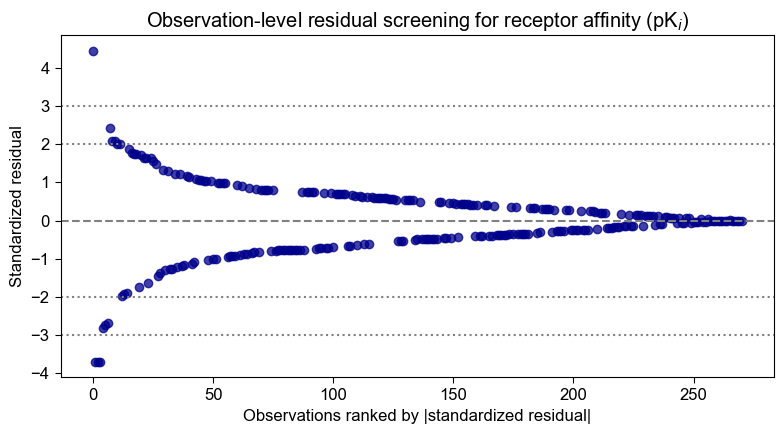


Observation-level influence summary (top suspicious observations):
 original_row_id substance  std_residual  max_abs_change  median_abs_change
              65   5311501     -3.696368        0.061372           0.006879
              66   5311501     -3.696368        0.061372           0.006879
              64   5311501     -3.695928        0.061365           0.006878
             270  44208932     -2.693721        0.060089           0.010814
             141    104850     -2.804132        0.052504           0.006366
              29  44208932      4.441255        0.045746           0.020201
              20   3081355     -2.748307        0.042305           0.013434
             218    104850      1.996184        0.026789           0.004316
             156    104895     -1.929171        0.025770           0.005092
             107   5311501      1.999806        0.019750           0.002812
             106   5311501      2.419392        0.018465           0.005232
             108   5

In [85]:
# ============================================================
# DIAGNOSTIC C: Observation-level influence diagnostics
# pKi MI-LMM

# ------------------------------------------------------------


# ------------------------------------------------------------
# 1) use shared imputed dataset and shared model
# ------------------------------------------------------------
df_obs_1 = df_imp_1_shared.copy()

# keep original row id for traceability
df_obs_1 = df_obs_1.reset_index(drop=False).rename(columns={"index": "original_row_id"})

res_obs_1 = res_imp_1_shared

# ------------------------------------------------------------
# 2) fitted values and residuals
# ------------------------------------------------------------
diag_obs_df = df_obs_1.copy()

diag_obs_df["fitted"] = res_obs_1.fittedvalues.astype(float).values
diag_obs_df["residual"] = res_obs_1.resid.astype(float).values
diag_obs_df["std_residual"] = diag_obs_df["residual"] / np.sqrt(res_obs_1.scale)
diag_obs_df["abs_std_residual"] = diag_obs_df["std_residual"].abs()

# sort by most extreme residuals
diag_obs_df = diag_obs_df.sort_values(
    "abs_std_residual",
    ascending=False
).reset_index(drop=True)

print("Top observations by absolute standardized residual:")
cols_to_show = [
    "original_row_id", GROUP, Y, "fitted", "residual", "std_residual"
]
print(diag_obs_df[cols_to_show].head(15).to_string(index=False))

# ------------------------------------------------------------
# 3) plot: standardized residuals by observation rank
# ------------------------------------------------------------
plt.figure(figsize=(8, 4.5))

plt.scatter(
    range(len(diag_obs_df)),
    diag_obs_df["std_residual"],
    alpha=0.75,
    color="darkblue"
)

plt.axhline(0, linestyle="--", color="grey")
plt.axhline(2, linestyle=":", color="grey")
plt.axhline(-2, linestyle=":", color="grey")
plt.axhline(3, linestyle=":", color="grey")
plt.axhline(-3, linestyle=":", color="grey")

plt.xlabel("Observations ranked by |standardized residual|")
plt.ylabel("Standardized residual")
plt.title("Observation-level residual screening for receptor affinity (pK$_i$)")

plt.tight_layout()
plt.savefig("observations_ranked_pKi.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4) define baseline coefficients from shared model
# ------------------------------------------------------------
baseline_params = res_obs_1.fe_params.copy()

# ------------------------------------------------------------
# 5) leave-one-observation-out for top suspicious observations
# ------------------------------------------------------------
TOP_N = 15

top_obs = diag_obs_df.head(TOP_N).copy()

loo_obs_rows = []
failed_obs = []

for _, row in top_obs.iterrows():
    row_id = row["original_row_id"]

    df_minus_one = df_obs_1[df_obs_1["original_row_id"] != row_id].copy()

    try:
        res_minus_one = fit_mixedlm_safe(
            formula=formula_fixed,
            data=df_minus_one,
            group_col=GROUP,
            categorical_cols=CATS,
            reml=USE_REML_FINAL
        )

        params_minus_one = res_minus_one.fe_params.copy()

        merged = pd.DataFrame({
            "term": baseline_params.index,
            "estimate_full": baseline_params.values,
            "estimate_minus_one": params_minus_one.reindex(baseline_params.index).values
        })

        merged["original_row_id"] = row_id
        merged["substance"] = str(row[GROUP])
        merged["std_residual"] = float(row["std_residual"])

        merged["abs_change"] = (
            merged["estimate_minus_one"] - merged["estimate_full"]
        ).abs()

        merged["rel_change_pct"] = np.where(
            merged["estimate_full"].abs() > 1e-8,
            100 * merged["abs_change"] / merged["estimate_full"].abs(),
            np.nan
        )

        loo_obs_rows.append(merged)

    except Exception as e:
        failed_obs.append({
            "original_row_id": row_id,
            "substance": str(row[GROUP]),
            "std_residual": float(row["std_residual"]),
            "error": str(e)
        })

if len(loo_obs_rows) == 0:
    raise RuntimeError("All leave-one-observation-out fits failed for the selected observations.")

loo_obs_df = pd.concat(loo_obs_rows, ignore_index=True)

# ------------------------------------------------------------
# 6) summarize which observations have strongest impact
# ------------------------------------------------------------
obs_influence_summary = (
    loo_obs_df.groupby(["original_row_id", "substance", "std_residual"], as_index=False)
    .agg(
        max_abs_change=("abs_change", "max"),
        median_abs_change=("abs_change", "median")
    )
    .sort_values("max_abs_change", ascending=False)
)

print("\nObservation-level influence summary (top suspicious observations):")
print(obs_influence_summary.to_string(index=False))

# ------------------------------------------------------------
# 7) summarize which coefficients are most sensitive
# ------------------------------------------------------------
coef_sensitivity_summary = (
    loo_obs_df.groupby("term", as_index=False)
    .agg(
        max_abs_change=("abs_change", "max"),
        median_abs_change=("abs_change", "median")
    )
    .sort_values("max_abs_change", ascending=False)
)

print("\nCoefficient sensitivity to deleting one suspicious observation:")
print(coef_sensitivity_summary.to_string(index=False))

# ------------------------------------------------------------
# 8) detailed output for selected key terms
# ------------------------------------------------------------
key_terms = [
    "Intercept",
    "C(cell_cleaned, Treatment(reference='hek'))[T.cho]",
    "C(cell_cleaned, Treatment(reference='hek'))[T.chem-1]",
    "incubation_time",
    "temp",
    "log10_concentration_radioligand_nM"
]

detail_obs = loo_obs_df[loo_obs_df["term"].isin(key_terms)].copy()
detail_obs = detail_obs.sort_values(["term", "abs_change"], ascending=[True, False])

print("\nDetailed observation-level influence results for selected terms:")
print(detail_obs.to_string(index=False))

# ------------------------------------------------------------
# 9) optional: failed fits
# ------------------------------------------------------------
if len(failed_obs) > 0:
    failed_obs_df = pd.DataFrame(failed_obs)
    print("\nLeave-one-observation-out fits with errors:")
    print(failed_obs_df.to_string(index=False))
else:
    print("\nAll leave-one-observation-out fits completed without recorded errors.")

## Figures main manuscript

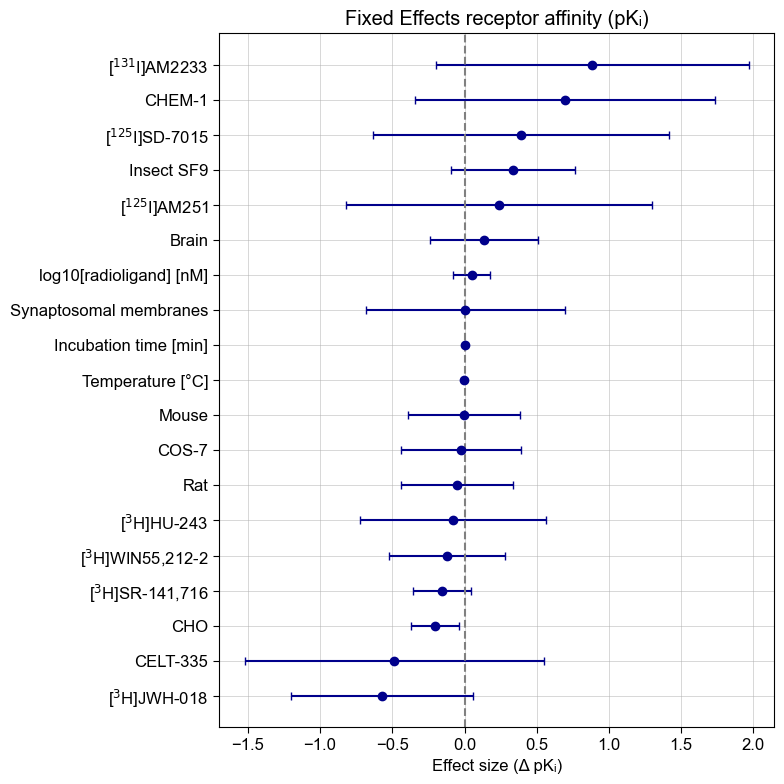

In [86]:
# ============================================================
# Fixed-effects plot for MULTIPLE IMPUTATION pooled results
# uses: pooled_fixed
# expected columns in pooled_fixed:
#   term, estimate, ci_low_95, ci_high_95
# ============================================================


# ------------------------------------------------------------
# 1) helper: raw parameter name -> pretty label
# ------------------------------------------------------------
def pretty_param_mi(name: str) -> str:
    if name == "Intercept":
        return name

    # numeric predictors
    num_map = {
        "incubation_time": "Incubation time [min]",
        "temp": "Temperature [°C]",
        "log10_concentration_radioligand_nM": "log10[radioligand] [nM]",
    }
    if name in num_map:
        return num_map[name]

    # receptor species
    m_species = re.match(
        r"C\(receptor_species, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_species:
        lvl = m_species.group(1)
        lvl_map = {
            "mouse": "Mouse",
            "rat": "Rat",
            "human": "Human",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # reference substance
    m_ref = re.match(
        r"C\(reference_substance, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_ref:
        lvl = m_ref.group(1)
        lvl_map = {
            "CELT-335": "CELT-335",
            "[125I]AM251": "[$^{125}$I]AM251",
            "[125I]SD-7015": "[$^{125}$I]SD-7015",
            "[131I]AM2233": "[$^{131}$I]AM2233",
            "[35S]GTPγS": "[$^{35}$S]GTPγS",
            "[3H]HU-243": "[$^3$H]HU-243",
            "[3H]JWH-018": "[$^3$H]JWH-018",
            "[3H]SR-141,716": "[$^3$H]SR-141,716",
            "[3H]WIN-55212-2": "[$^3$H]WIN55,212-2",
            "[3H]CP-55940": "[$^3$H]CP-55940",
        }
        return lvl_map.get(lvl, lvl)

    # cell membrane
    m_cell = re.match(
        r"C\(cell_cleaned, Treatment\(reference='[^']+'\)\)\[T\.(.+)\]", name
    )
    if m_cell:
        lvl = m_cell.group(1)
        lvl_map = {
            "brain": "Brain",
            "chem-1": "CHEM-1",
            "cho": "CHO",
            "cos": "COS-7",
            "insect SF9": "Insect SF9",
            "synaptosomal membranes": "Synaptosomal membranes",
            "hek": "HEK",
        }
        return lvl_map.get(lvl, lvl.replace("_", " "))

    # fallback
    return name.replace("_", " ")


# ------------------------------------------------------------
# 2) plotting function for pooled MI results
# ------------------------------------------------------------
def plot_fixed_effects_mi(
    pooled_df,
    title="Fixed Effects receptor affinity (pKᵢ)",
    x_label="Effect size (Δ pKᵢ)",
    outfile="Fixed_effects_pKi_MI.tiff",
    drop_intercept=True
):
    # keep only required columns
    plot_df = pooled_df[["term", "estimate", "ci_low_95", "ci_high_95"]].copy()

    if drop_intercept:
        plot_df = plot_df[plot_df["term"] != "Intercept"].copy()

    # pretty labels
    plot_df["label"] = plot_df["term"].apply(pretty_param_mi)

    # sort by estimate
    plot_df = plot_df.sort_values("estimate").reset_index(drop=True)

    # plot
    #plt.figure(figsize=(8, len(plot_df) * 0.5 + 1))
    plt.figure(figsize=(8, 8))
    plt.errorbar(
        plot_df["estimate"],
        plot_df["label"],
        xerr=[
            plot_df["estimate"] - plot_df["ci_low_95"],
            plot_df["ci_high_95"] - plot_df["estimate"]
        ],
        fmt="o",
        capsize=3,
        color="darkblue",
        ecolor="darkblue"
    )
    plt.axvline(0, color="grey", linestyle="--")
    plt.title(title)
    plt.xlabel(x_label)
    plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300)
    plt.show()

    return plot_df


# ------------------------------------------------------------
# 3) call
# ------------------------------------------------------------
plot_df_mi = plot_fixed_effects_mi(
    pooled_df=pooled_fixed,
    title="Fixed Effects receptor affinity (pKᵢ)",
    x_label="Effect size (Δ pKᵢ)",
    outfile="Fixed_effects_pKi_MI.png"
)

# Summary of dataset

In [53]:
data.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,2.710000e+02,271.000000,271.000000,207.000000,77.000000,228.000000,193.000000
mean,3.664807e+06,125.142291,7.860242,1.127836,11.526870,80.000000,30.611399
std,7.242653e+06,557.619331,0.827556,2.514378,78.935863,35.572721,12.889324
min,1.607800e+04,0.316200,5.249646,0.000028,0.017000,15.000000,4.000000
25%,1.048500e+05,3.940000,7.337242,0.270000,0.180000,60.000000,30.000000
50%,1.048950e+05,12.590000,7.899974,0.500000,0.690000,60.000000,30.000000
75%,5.311501e+06,46.000000,8.404554,1.000000,1.130000,90.000000,30.000000
max,4.420893e+07,5628.000000,9.500038,20.000000,690.000000,360.000000,200.000000


In [54]:
print(data["pubchem_cid"].value_counts())

pubchem_cid
104850      76
5311501     63
104895      34
16078       28
5281969     28
10382701    11
638026       9
3081355      9
44208932     7
6918505      6
Name: count, dtype: int64


In [55]:

print(data["reference_substance"].value_counts())
print(data["cell_cleaned"].value_counts())
print(data["receptor_species"].value_counts())


reference_substance
[3H]CP-55940       211
[3H]SR-141,716      39
[3H]WIN-55212-2      8
[3H]HU-243           5
[3H]JWH-018          3
[125I]SD-7015        1
[131I]AM2233         1
[125I]AM251          1
CELT-335             1
Name: count, dtype: int64
cell_cleaned
hek                       103
brain                      70
cho                        69
cos                         7
insect SF9                  6
synaptosomal membranes      3
chem-1                      1
Name: count, dtype: int64
receptor_species
human    190
rat       58
mouse     21
Name: count, dtype: int64


## Rimonabant

In [56]:
Rimonabant_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,76.0,76.000000,76.000000,56.000000,27.000000,65.000000,52.000000
mean,104850.0,10.332478,8.279346,1.577857,1.851370,72.230769,29.461538
std,0.0,17.957797,0.507004,3.694026,2.922002,25.556781,3.012793
min,104850.0,0.400000,6.844664,0.040000,0.017000,45.000000,20.000000
25%,104850.0,1.800000,7.920819,0.375000,0.180000,60.000000,30.000000
50%,104850.0,6.190000,8.208310,0.710000,0.800000,60.000000,30.000000
75%,104850.0,12.000000,8.744727,1.000000,1.185000,90.000000,30.000000
max,104850.0,143.000000,9.397940,20.000000,10.100000,180.000000,37.000000


In [57]:
print(Rimonabant_df["reference_substance"].value_counts())
print(Rimonabant_df["cell_cleaned"].value_counts())
print(Rimonabant_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       49
[3H]SR-141,716     22
[3H]WIN-55212-2     2
[3H]JWH-018         1
[125I]SD-7015       1
[125I]AM251         1
Name: count, dtype: int64
cell_cleaned
hek      33
cho      24
brain    16
Name: count, dtype: int64
receptor_species
human    57
rat      14
mouse     4
Name: count, dtype: int64


## WIN-55212

In [58]:
WIN_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,63.0,63.000000,63.000000,46.000000,16.00000,51.000000,45.000000
mean,5311501.0,204.819683,7.670228,0.698261,1.57625,80.000000,29.555556
std,0.0,811.034692,0.654662,0.829919,2.73272,18.654758,1.438995
min,5311501.0,1.600000,5.419988,0.100000,0.11000,60.000000,25.000000
25%,5311501.0,11.150000,7.419616,0.400000,0.18000,60.000000,30.000000
50%,5311501.0,20.000000,7.698970,0.500000,0.76000,90.000000,30.000000
75%,5311501.0,38.100000,7.952764,0.800000,1.13000,90.000000,30.000000
max,5311501.0,3802.000000,8.795880,5.000000,10.10000,120.000000,30.000000


In [59]:
print(WIN_df["reference_substance"].value_counts())
print(WIN_df["cell_cleaned"].value_counts())
print(WIN_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       53
[3H]SR-141,716      5
[3H]WIN-55212-2     3
[131I]AM2233        1
Name: count, dtype: int64
cell_cleaned
hek           23
cho           20
brain         11
insect SF9     3
cos            2
Name: count, dtype: int64
receptor_species
human    50
rat       9
mouse     4
Name: count, dtype: int64


## CP-55,940

In [60]:
CP_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,34.0,34.000000,34.000000,26.000000,5.000000,27.000000,25.000000
mean,104895.0,2.545518,8.867130,1.055731,1.412000,84.444444,30.800000
std,0.0,3.452438,0.458761,0.862285,0.913165,26.360421,4.600725
min,104895.0,0.316200,7.886057,0.100000,0.390000,30.000000,21.000000
25%,104895.0,0.605000,8.780548,0.500000,0.720000,60.000000,30.000000
50%,104895.0,1.249500,8.903276,0.900000,1.240000,90.000000,30.000000
75%,104895.0,1.657500,9.218289,1.059250,2.310000,105.000000,37.000000
max,104895.0,13.000000,9.500038,3.500000,2.400000,120.000000,37.000000


In [61]:
print(CP_df["reference_substance"].value_counts())
print(CP_df["cell_cleaned"].value_counts())
print(CP_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       28
[3H]SR-141,716      5
[3H]WIN-55212-2     1
Name: count, dtype: int64
cell_cleaned
cho           13
hek           10
brain          7
insect SF9     3
Name: count, dtype: int64
receptor_species
human    27
rat       5
mouse     2
Name: count, dtype: int64


## Anandamide

In [62]:
Anandamide_2_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,28.0,28.000000,28.000000,23.000000,11.000000,24.000000,17.000000
mean,5281969.0,132.364286,7.048884,1.579132,8.140909,66.250000,40.000000
std,0.0,159.828974,0.364278,4.265662,25.161698,12.445534,41.231056
min,5281969.0,11.000000,6.096910,0.000038,0.180000,60.000000,30.000000
25%,5281969.0,70.000000,7.045757,0.140000,0.180000,60.000000,30.000000
50%,5281969.0,73.000000,7.136718,0.500000,0.690000,60.000000,30.000000
75%,5281969.0,90.000000,7.154902,0.800000,0.825000,60.000000,30.000000
max,5281969.0,800.000000,7.958607,20.000000,84.000000,90.000000,200.000000


In [63]:
print(Anandamide_2_df["reference_substance"].value_counts())
print(Anandamide_2_df["cell_cleaned"].value_counts())
print(Anandamide_2_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       21
[3H]SR-141,716      4
[3H]HU-243          2
[3H]WIN-55212-2     1
Name: count, dtype: int64
cell_cleaned
brain                     15
hek                        7
cos                        4
cho                        1
synaptosomal membranes     1
Name: count, dtype: int64
receptor_species
rat      15
human    11
mouse     2
Name: count, dtype: int64


## 9-THC

In [64]:
THC9_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,28.0,28.000000,28.000000,22.000000,1.0,25.000000,21.000000
mean,16078.0,31.701071,7.644996,0.811047,6.5,100.200000,29.476190
std,0.0,22.200658,0.428874,1.206832,NaN,60.733022,7.124739
min,16078.0,1.050000,7.086186,0.000028,6.5,15.000000,4.000000
25%,16078.0,16.575000,7.356869,0.200000,6.5,90.000000,30.000000
50%,16078.0,26.500000,7.577995,0.500000,6.5,90.000000,30.000000
75%,16078.0,43.982500,7.780990,0.950000,6.5,120.000000,30.000000
max,16078.0,82.000000,8.978811,5.400000,6.5,360.000000,37.000000


In [65]:
print(THC9_df["reference_substance"].value_counts())
print(THC9_df["cell_cleaned"].value_counts())
print(THC9_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940      21
[3H]HU-243         3
[3H]SR-141,716     2
[3H]JWH-018        1
CELT-335           1
Name: count, dtype: int64
cell_cleaned
hek                       10
brain                      8
cho                        4
synaptosomal membranes     2
chem-1                     1
cos                        1
Name: count, dtype: int64
receptor_species
human    16
rat       8
mouse     4
Name: count, dtype: int64


## JWH-018

In [66]:
JWH018_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,11.0,11.000000,11.000000,9.000000,4.000000,10.000000,10.000000
mean,10382701.0,4.644091,8.417196,1.122222,176.020000,96.000000,27.800000
std,0.0,3.043681,0.284284,0.982061,342.662859,93.594872,9.283199
min,10382701.0,1.300000,8.020000,0.200000,1.080000,60.000000,4.000000
25%,10382701.0,2.625000,8.201309,0.500000,5.145000,60.000000,26.250000
50%,10382701.0,3.400000,8.468521,0.600000,6.500000,60.000000,30.000000
75%,10382701.0,6.720000,8.581004,2.000000,177.375000,82.500000,30.000000
max,10382701.0,9.500000,8.886057,3.000000,690.000000,360.000000,37.000000


In [67]:
print(JWH018_df["reference_substance"].value_counts())
print(JWH018_df["cell_cleaned"].value_counts())
print(JWH018_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940       8
[3H]SR-141,716     1
[3H]WIN-55212-2    1
[3H]JWH-018        1
Name: count, dtype: int64
cell_cleaned
brain    4
cho      4
hek      3
Name: count, dtype: int64
receptor_species
human    7
rat      2
mouse    1
Name: count, dtype: int64


## SR144528

In [68]:
SR_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,9.0,9.000000,9.000000,8.000000,7.000000,8.000000,8.000000
mean,3081355.0,824.310000,6.599262,0.472500,0.582857,97.500000,29.375000
std,0.0,1812.234215,0.582094,0.825932,1.065860,34.948942,1.767767
min,3081355.0,116.000000,5.249646,0.140000,0.180000,60.000000,25.000000
25%,3081355.0,116.790000,6.397940,0.140000,0.180000,90.000000,30.000000
50%,3081355.0,117.000000,6.930000,0.140000,0.180000,90.000000,30.000000
75%,3081355.0,400.000000,6.932594,0.215000,0.180000,90.000000,30.000000
max,3081355.0,5628.000000,6.935542,2.500000,3.000000,180.000000,30.000000


In [69]:
print(SR_df["reference_substance"].value_counts())
print(SR_df["cell_cleaned"].value_counts())
print(SR_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    9
Name: count, dtype: int64
cell_cleaned
hek    7
cho    1
Name: count, dtype: int64
receptor_species
human    9
Name: count, dtype: int64


## delta8-THC

In [70]:
THC8_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,9.0,9.000000,9.000000,6.000000,2.000,6.00000,5.000000
mean,638026.0,77.466667,7.308680,1.996667,0.186,85.00000,32.800000
std,0.0,107.394821,0.380298,1.896119,0.000,22.58318,3.834058
min,638026.0,15.400000,6.443697,0.500000,0.186,60.00000,30.000000
25%,638026.0,28.500000,7.322393,1.000000,0.186,67.50000,30.000000
50%,638026.0,47.600000,7.322393,1.000000,0.186,90.00000,30.000000
75%,638026.0,47.600000,7.545155,2.560000,0.186,90.00000,37.000000
max,638026.0,360.000000,7.812479,5.400000,0.186,120.00000,37.000000


In [71]:
print(THC8_df["reference_substance"].value_counts())
print(THC8_df["cell_cleaned"].value_counts())
print(THC8_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    9
Name: count, dtype: int64
cell_cleaned
hek      4
brain    4
cho      1
Name: count, dtype: int64
receptor_species
human    5
rat      4
Name: count, dtype: int64


## CHEMBL381689

In [72]:
CHEMBL_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,7.0,7.000000,7.000000,6.000000,1.00,6.000000,5.0
mean,44208932.0,567.771429,7.017255,0.556667,0.18,65.000000,30.0
std,0.0,1040.207303,1.209316,0.489966,NaN,12.247449,0.0
min,44208932.0,0.400000,5.539102,0.140000,0.18,60.000000,30.0
25%,44208932.0,70.000000,6.359519,0.275000,0.18,60.000000,30.0
50%,44208932.0,70.000000,7.154902,0.500000,0.18,60.000000,30.0
75%,44208932.0,437.000000,7.154902,0.500000,0.18,60.000000,30.0
max,44208932.0,2890.000000,9.397940,1.500000,0.18,90.000000,30.0


In [73]:
print(CHEMBL_df["reference_substance"].value_counts())
print(CHEMBL_df["cell_cleaned"].value_counts())
print(CHEMBL_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    7
Name: count, dtype: int64
cell_cleaned
hek      3
brain    3
cho      1
Name: count, dtype: int64
receptor_species
human    4
mouse    3
Name: count, dtype: int64


## JWH-133

In [74]:
JWH133_df.describe()

,pubchem_cid,value,value_pKi,concentration radioligand (nM),Kd,incubation_time,temp
count,6.0,6.000000,6.000000,5.000000,3.000000e+00,6.000000,5.0
mean,6918505.0,567.133333,6.313078,0.434000,1.800000e-01,75.000000,30.0
std,0.0,246.479587,0.313809,0.353384,3.399350e-17,16.431677,0.0
min,6918505.0,116.800000,6.098542,0.140000,1.800000e-01,60.000000,30.0
25%,6918505.0,512.750000,6.169411,0.140000,1.800000e-01,60.000000,30.0
50%,6918505.0,677.000000,6.169411,0.390000,1.800000e-01,75.000000,30.0
75%,6918505.0,677.000000,6.296704,0.500000,1.800000e-01,90.000000,30.0
max,6918505.0,797.000000,6.932557,1.000000,1.800000e-01,90.000000,30.0


In [75]:
print(JWH133_df["reference_substance"].value_counts())
print(JWH133_df["cell_cleaned"].value_counts())
print(JWH133_df["receptor_species"].value_counts())

reference_substance
[3H]CP-55940    6
Name: count, dtype: int64
cell_cleaned
hek      3
brain    2
Name: count, dtype: int64
receptor_species
human    4
rat      1
mouse    1
Name: count, dtype: int64
